In [2]:
source("config.r")

In [ ]:
library(ggplot2)
library(caret)
library(corrplot)
library(car)
library(dplyr)
library(tidyr)
library(pROC)
library(ranger)
library(rpart)
library(randomForest)
options(warn = -1)

# Data

## Dataset Overview

In [4]:
df.train <- read.csv(TRAINING_DATA_PATH)
df.test <- read.csv(TESTING_DATA_PATH)

str(df.train)

'data.frame':	440833 obs. of  12 variables:
 $ CustomerID       : int  2 3 4 5 6 8 9 10 11 12 ...
 $ Age              : int  30 65 55 58 23 51 58 55 39 64 ...
 $ Gender           : chr  "Female" "Female" "Female" "Male" ...
 $ Tenure           : int  39 49 14 38 32 33 49 37 12 3 ...
 $ Usage.Frequency  : int  14 1 4 21 20 25 12 8 5 25 ...
 $ Support.Calls    : int  5 10 6 7 5 9 3 4 7 2 ...
 $ Payment.Delay    : int  18 8 18 7 8 26 16 15 4 11 ...
 $ Subscription.Type: chr  "Standard" "Basic" "Basic" "Standard" ...
 $ Contract.Length  : chr  "Annual" "Monthly" "Quarterly" "Monthly" ...
 $ Total.Spend      : num  932 557 185 396 617 129 821 445 969 415 ...
 $ Last.Interaction : int  17 6 3 29 20 8 24 30 13 29 ...
 $ Churn            : int  1 1 1 1 1 1 1 1 1 1 ...


## Feature Description

In [5]:
preprocess <- function(df) {
  df$CustomerID <- NULL
  df$Gender <- as.factor(df$Gender)
  df$Subscription.Type <- as.factor(df$Subscription.Type)
  df$Contract.Length <- as.factor(df$Contract.Length)
  df$Churn <- as.factor(df$Churn)
  return(df)
}

df.train <- preprocess(df.train)
df.train$Churn.num <- as.numeric(as.character(df.train$Churn))

df.test <- preprocess(df.test)

summary(df.train)
summary(df.test)

      Age           Gender           Tenure      Usage.Frequency
 Min.   :18.00         :     1   Min.   : 1.00   Min.   : 1.00  
 1st Qu.:29.00   Female:190580   1st Qu.:16.00   1st Qu.: 9.00  
 Median :39.00   Male  :250252   Median :32.00   Median :16.00  
 Mean   :39.37                   Mean   :31.26   Mean   :15.81  
 3rd Qu.:48.00                   3rd Qu.:46.00   3rd Qu.:23.00  
 Max.   :65.00                   Max.   :60.00   Max.   :30.00  
 NA's   :1                       NA's   :1       NA's   :1      
 Support.Calls    Payment.Delay   Subscription.Type  Contract.Length  
 Min.   : 0.000   Min.   : 0.00           :     1            :     1  
 1st Qu.: 1.000   1st Qu.: 6.00   Basic   :143026   Annual   :177198  
 Median : 3.000   Median :12.00   Premium :148678   Monthly  : 87104  
 Mean   : 3.604   Mean   :12.97   Standard:149128   Quarterly:176530  
 3rd Qu.: 6.000   3rd Qu.:19.00                                       
 Max.   :10.000   Max.   :30.00                       

      Age           Gender          Tenure      Usage.Frequency
 Min.   :18.00   Female:34353   Min.   : 1.00   Min.   : 1.00  
 1st Qu.:30.00   Male  :30021   1st Qu.:18.00   1st Qu.: 7.00  
 Median :42.00                  Median :33.00   Median :15.00  
 Mean   :41.97                  Mean   :31.99   Mean   :15.08  
 3rd Qu.:54.00                  3rd Qu.:47.00   3rd Qu.:23.00  
 Max.   :65.00                  Max.   :60.00   Max.   :30.00  
 Support.Calls    Payment.Delay   Subscription.Type  Contract.Length 
 Min.   : 0.000   Min.   : 0.00   Basic   :21451    Annual   :21410  
 1st Qu.: 3.000   1st Qu.:10.00   Premium :21421    Monthly  :22130  
 Median : 6.000   Median :19.00   Standard:21502    Quarterly:20834  
 Mean   : 5.401   Mean   :17.13                                      
 3rd Qu.: 8.000   3rd Qu.:25.00                                      
 Max.   :10.000   Max.   :30.00                                      
  Total.Spend   Last.Interaction Churn    
 Min.   : 100   Min

In [6]:
check_missing <- function(df, df.name = "") {
  missing.idx <- which(!complete.cases(df))
  cat(df.name, ": Found", length(missing.idx), "missing rows\n")
  if (length(missing.idx) > 0) print(df[missing.idx, ], row.names = FALSE)
  invisible(missing.idx)
}

check_missing(df.train, "df.train")
check_missing(df.test, "df.test")

df.train : Found 1 missing rows
 Age Gender Tenure Usage.Frequency Support.Calls Payment.Delay
  NA            NA              NA            NA            NA
 Subscription.Type Contract.Length Total.Spend Last.Interaction Churn Churn.num
                                            NA               NA  <NA>        NA
df.test : Found 0 missing rows


In [7]:
df.train <- df.train[complete.cases(df.train), ]

# Exploratory Data Analysis

## Feature Distribution by Churn

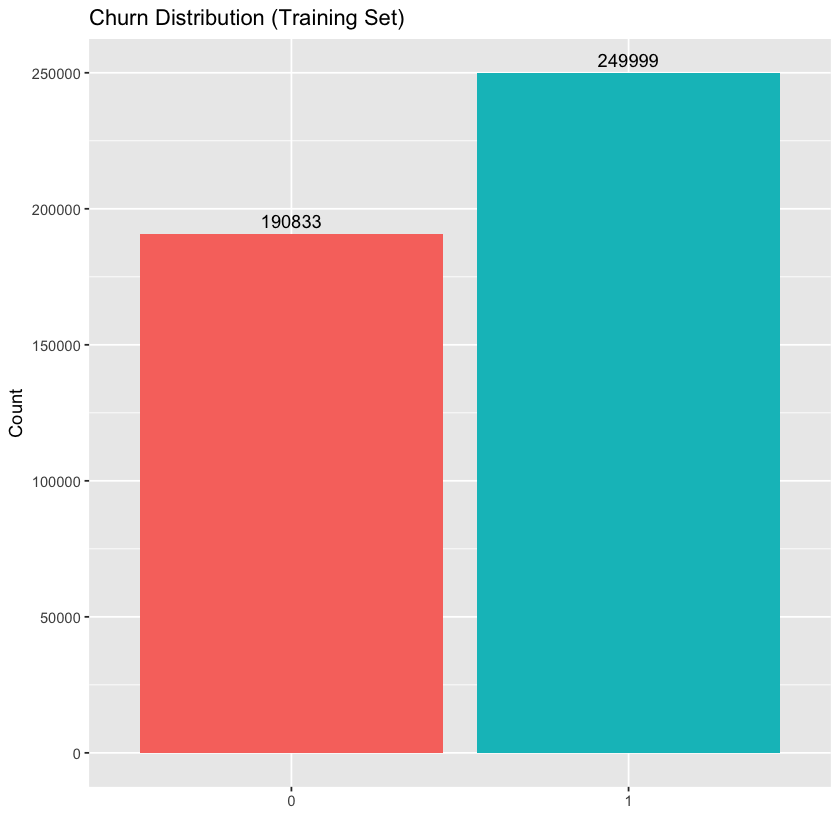

In [8]:
ggplot(df.train, aes(x = Churn, fill = Churn)) +
    geom_bar() +
    geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
    labs(title = "Churn Distribution (Training Set)",
         x = "", y = "Count") +
    theme(legend.position = "none")

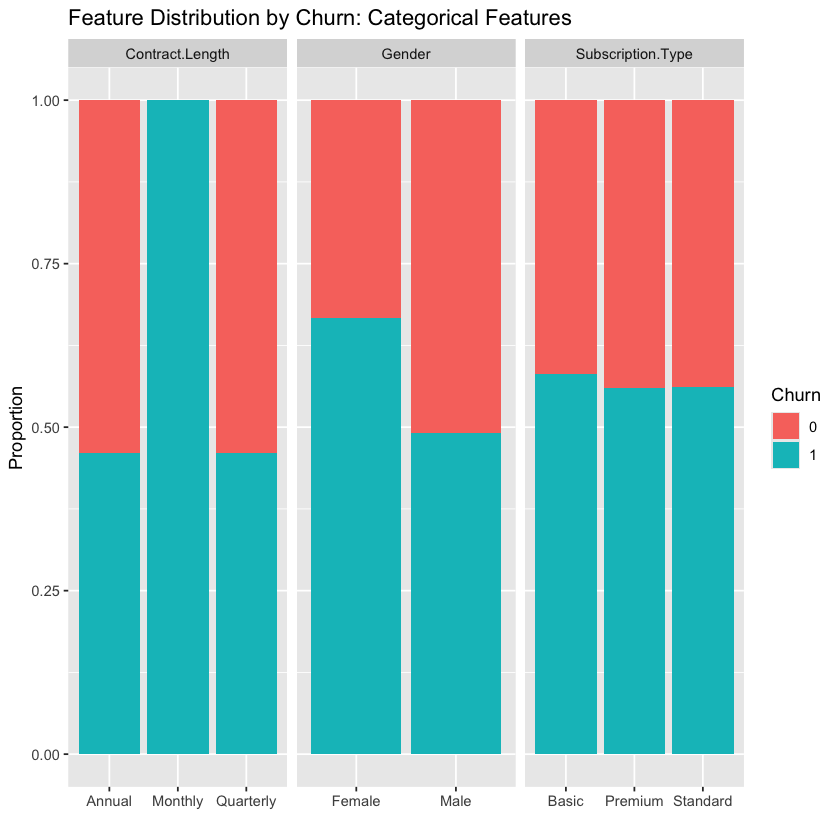

In [9]:
categorical.features <- c("Gender", "Subscription.Type", "Contract.Length")

df.cat.long <- pivot_longer(data = df.train[, c("Churn", categorical.features)],
                            cols = -Churn,
                            names_to = "feature",
                            values_to = "value")

ggplot(df.cat.long, aes(x = value, fill = Churn)) + 
    geom_bar(position = "fill")+
    facet_wrap(~feature, scales = "free_x")+
    labs(title = "Feature Distribution by Churn: Categorical Features",
         x = "", y = "Proportion")

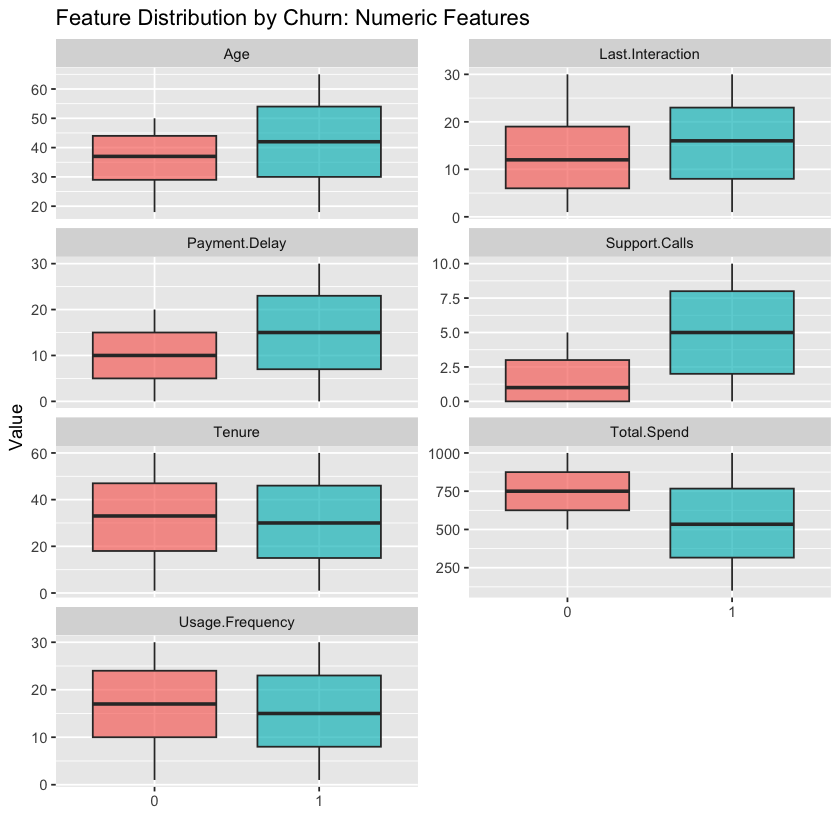

In [77]:
numeric.features <- c("Age", "Tenure", "Usage.Frequency", "Support.Calls", 
                  "Payment.Delay", "Total.Spend", "Last.Interaction")

df.long <- pivot_longer(data = df.train[, c("Churn", numeric.features)],
                        cols = -Churn,
                        names_to = "feature",
                        values_to = "value")

ggplot(df.long, aes(x = Churn, y = value, fill = Churn)) +
    geom_boxplot(outlier.size = 0.5, alpha = 0.7) + 
    facet_wrap(~ feature, scales = "free_y", ncol = 2) + 
    labs(title = "Feature Distribution by Churn: Numeric Features", 
         x = "", y = "Value") + 
    theme(legend.position = "none")

## Feature Correlation

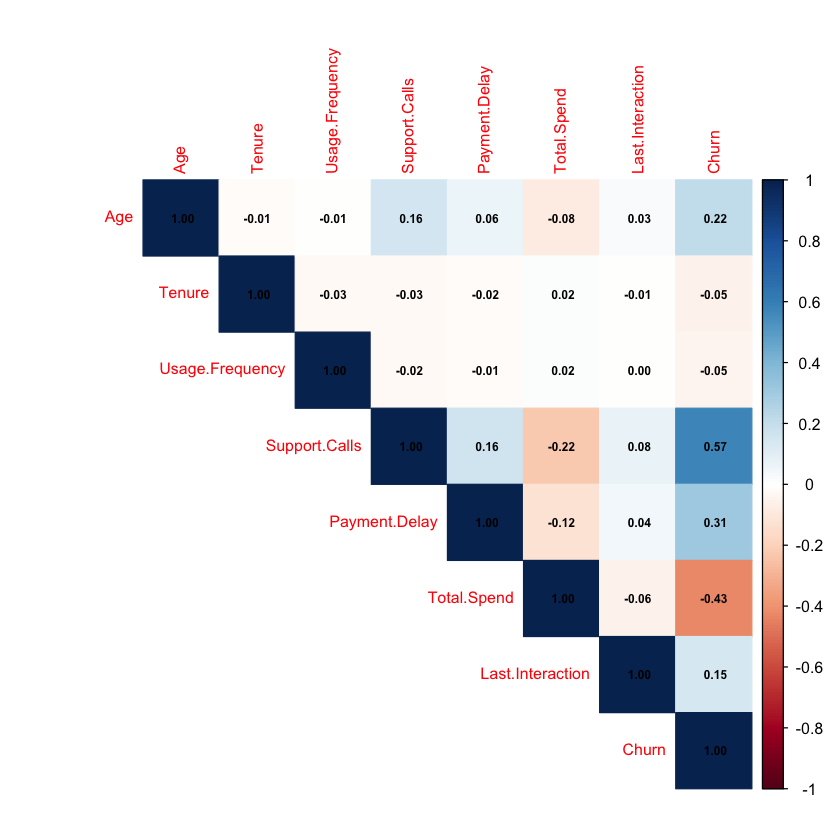

In [11]:
cor.data <- df.train[, numeric.features]
cor.data$Churn <- df.train$Churn.num

corrplot(cor(cor.data, use = "complete.obs"),
    method = "color",
    type = "upper",
    tl.cex = 0.8, 
    addCoef.col = "black",
    number.cex = 0.6)

## Multicollinearity Check (VIF)

In [42]:
compute_vif <- function(data) {
  lm.proxy <- lm(Churn.num ~ . - Churn, data = data)
  vif.result <- vif(lm.proxy)
  vif.data <- data.frame(
    Feature = rownames(vif.result),
    VIF     = round(vif.result[, 1], 3)
  )
  print(vif.data, row.names = FALSE)
  invisible(vif.data)
}

compute_vif(df.train)

           Feature   VIF
               Age 1.032
            Gender 1.036
            Tenure 1.003
   Usage.Frequency 1.002
     Support.Calls 1.138
     Payment.Delay 1.045
 Subscription.Type 1.001
   Contract.Length 1.082
       Total.Spend 1.080
  Last.Interaction 1.032


## Feature Selection (AIC)

In [79]:
aic.result <- feature_select(df.train)

Start:  AIC=214868.2
Churn ~ (Age + Gender + Tenure + Usage.Frequency + Support.Calls + 
    Payment.Delay + Subscription.Type + Contract.Length + Total.Spend + 
    Last.Interaction + Churn.num) - Churn.num

                    Df Deviance    AIC
<none>                   214842 214868
- Subscription.Type  2   214951 214973
- Usage.Frequency    1   215383 215407
- Tenure             1   215439 215463
- Age                1   220183 220207
- Last.Interaction   1   223211 223235
- Gender             1   224933 224957
- Payment.Delay      1   239132 239156
- Total.Spend        1   270242 270266
- Contract.Length    2   291659 291681
- Support.Calls      1   335160 335184


# Methodology

## Machine Learning Models

In [78]:
feature_select <- function(data, k = 2) {
  full.glm <- glm(Churn ~ . - Churn.num, data = data, family = "binomial")
  step.result <- stats::step(full.glm, direction = "backward", k = k)
  summary(step.result)
  invisible(step.result)
}

In [ ]:
ctrl <- trainControl(method = "cv", number = 5)

In [15]:
train_glm <- function(data, ctrl) {
  set.seed(42)
  model <- train(Churn ~ Age + Gender + Tenure + Usage.Frequency + 
                   Support.Calls + Payment.Delay + Subscription.Type + Contract.Length + 
                   Total.Spend + Last.Interaction,
                 data = data,
                 method = "glm",
                 family = "binomial",
                 trControl = ctrl,
                 maxit = 300,
                 trace = FALSE)
  return(model)
}

In [49]:
train_glm_bic <- function(data, ctrl) {
  set.seed(42)
  model <- train(Churn ~ Age + Gender + Usage.Frequency + 
                   Support.Calls + Payment.Delay + Subscription.Type + Contract.Length + 
                   Total.Spend + Last.Interaction,
                 data = data,
                 method = "glm",
                 family = "binomial",
                 trControl = ctrl,
                 maxit = 300,
                 trace = FALSE)
  return(model)
}

In [31]:
train_rf <- function(data, ctrl, sample.size = 50000) {
  set.seed(42)
  idx <- sample(nrow(data), sample.size)
  model <- train(Churn ~ Age + Gender + Tenure + Usage.Frequency + 
                   Support.Calls + Payment.Delay + Subscription.Type + 
                   Contract.Length + Total.Spend + Last.Interaction,
                 data = data[idx, ],
                 method = "rf",
                 trControl = ctrl)
  return(model)
}

In [17]:
eval_model <- function(model, test.data) {
  pred    <- predict(model, newdata = test.data, type = "raw")
  prob    <- predict(model, newdata = test.data, type = "prob")[, "1"]
  cm      <- confusionMatrix(pred, test.data$Churn, positive = "1")
  auc_val <- auc(roc(as.numeric(as.character(test.data$Churn)), prob, quiet = TRUE))

  print(cm$table)

  results <- data.frame(
    Accuracy    = round(cm$overall["Accuracy"], 4),
    Sensitivity = round(cm$byClass["Sensitivity"], 4),
    Specificity = round(cm$byClass["Specificity"], 4),
    F1          = round(cm$byClass["F1"], 4),
    AUC         = round(auc_val, 4)
  )
  print(results, row.names = FALSE)
  invisible(results)
}

# Results

## Original Split

In [18]:
cv.model.original <- train_glm(df.train, ctrl)
eval_model(cv.model.original, df.test)

          Reference
Prediction     0     1
         0  6566   287
         1 27315 30206
 Accuracy Sensitivity Specificity     F1    AUC
   0.5712      0.9906      0.1938 0.6864 0.6831


## Distribution Shift Analysis

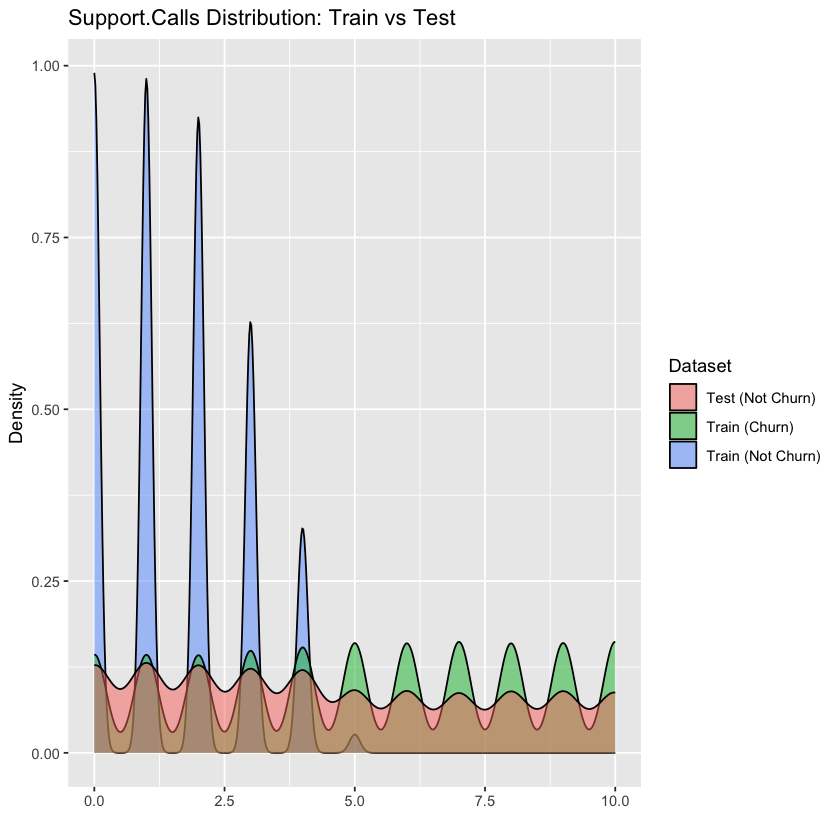

In [19]:
ggplot() +
    geom_density(data = df.train[df.train$Churn == 0, ], 
                 aes(x = Support.Calls, fill = "Train (Not Churn)"), alpha = 0.5) +
    geom_density(data = df.train[df.train$Churn == 1, ], 
                 aes(x = Support.Calls, fill = "Train (Churn)"), alpha = 0.5) +
    geom_density(data = df.test[df.test$Churn == 0, ], 
                 aes(x = Support.Calls, fill = "Test (Not Churn)"), alpha = 0.5) +
    labs(title = "Support.Calls Distribution: Train vs Test",
         x = "", y = "Density", fill = "Dataset")

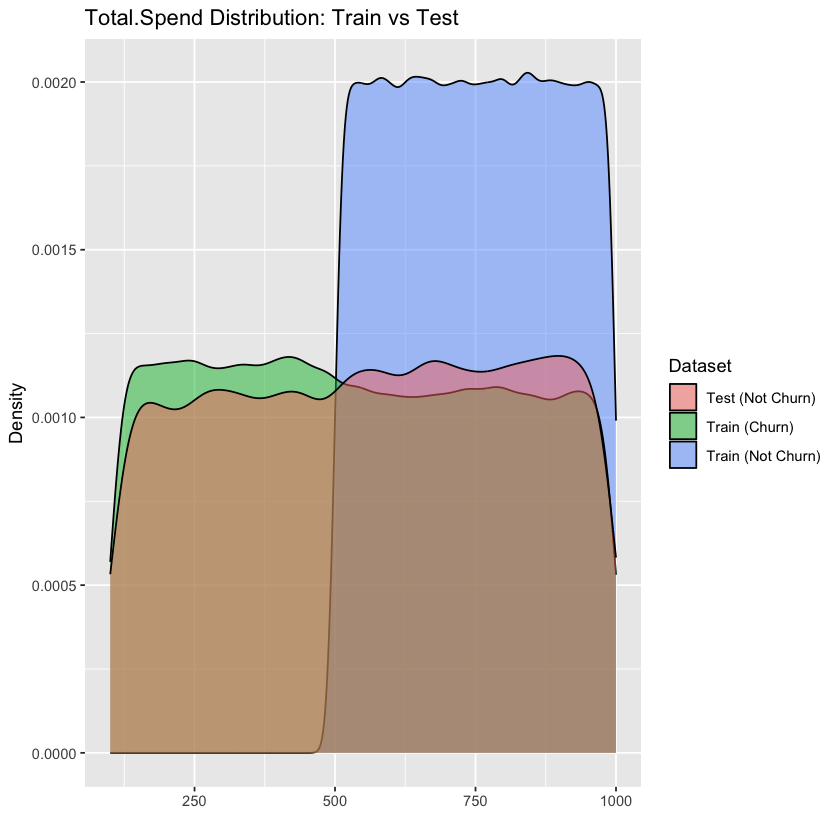

In [20]:
ggplot() +
    geom_density(data = df.train[df.train$Churn == 0, ], 
                 aes(x = Total.Spend, fill = "Train (Not Churn)"), alpha = 0.5) +
    geom_density(data = df.train[df.train$Churn == 1, ], 
                 aes(x = Total.Spend, fill = "Train (Churn)"), alpha = 0.5) +
    geom_density(data = df.test[df.test$Churn == 0, ], 
                 aes(x = Total.Spend, fill = "Test (Not Churn)"), alpha = 0.5) +
    labs(title = "Total.Spend Distribution: Train vs Test",
         x = "", y = "Density", fill = "Dataset")

## Re-split

In [ ]:
df.all <- rbind(df.train[, names(df.test)], df.test)

set.seed(42)
train_idx <- sample(nrow(df.all), 0.8 * nrow(df.all))
df.train.new <- preprocess(df.all[train_idx, ])
df.test.new  <- preprocess(df.all[-train_idx, ])
df.train.new <- droplevels(preprocess(df.all[train_idx, ]))
df.test.new  <- droplevels(preprocess(df.all[-train_idx, ]))
df.train.new$Churn.num <- as.numeric(as.character(df.train.new$Churn))

## Feature Selection (Re-split) 

In [80]:
aic.result <- feature_select(df.train.new, k = 2)
bic.result <- feature_select(df.train.new, k = log(nrow(df.train.new)))

formula(aic.result)
formula(bic.result)

Start:  AIC=314558.2
Churn ~ (Age + Gender + Tenure + Usage.Frequency + Support.Calls + 
    Payment.Delay + Subscription.Type + Contract.Length + Total.Spend + 
    Last.Interaction + Churn.num) - Churn.num

                    Df Deviance    AIC
<none>                   314532 314558
- Tenure             1   314543 314567
- Subscription.Type  2   314592 314614
- Usage.Frequency    1   315170 315194
- Last.Interaction   1   318310 318334
- Age                1   318548 318572
- Gender             1   320847 320871
- Payment.Delay      1   337855 337879
- Total.Spend        1   341727 341751
- Contract.Length    2   343666 343688
- Support.Calls      1   384866 384890
Start:  AIC=314700
Churn ~ (Age + Gender + Tenure + Usage.Frequency + Support.Calls + 
    Payment.Delay + Subscription.Type + Contract.Length + Total.Spend + 
    Last.Interaction + Churn.num) - Churn.num

                    Df Deviance    AIC
- Tenure             1   314543 314698
<none>                   314532 314700

Churn ~ (Age + Gender + Tenure + Usage.Frequency + Support.Calls + 
    Payment.Delay + Subscription.Type + Contract.Length + Total.Spend + 
    Last.Interaction + Churn.num) - Churn.num
<environment: 0x16aa06c18>

Churn ~ Age + Gender + Usage.Frequency + Support.Calls + Payment.Delay + 
    Subscription.Type + Contract.Length + Total.Spend + Last.Interaction
<environment: 0x17d459bd8>

## Re-split: Logistic Regression (AIC)

In [ ]:
cv.model.aic <- train_glm(df.train.new, ctrl)
eval_model(cv.model.aic, df.test.new)

Start:  AIC=314558.2
Churn ~ (Age + Gender + Tenure + Usage.Frequency + Support.Calls + 
    Payment.Delay + Subscription.Type + Contract.Length + Total.Spend + 
    Last.Interaction + Churn.num) - Churn.num

                    Df Deviance    AIC
<none>                   314532 314558
- Tenure             1   314543 314567
- Subscription.Type  2   314592 314614
- Usage.Frequency    1   315170 315194
- Last.Interaction   1   318310 318334
- Age                1   318548 318572
- Gender             1   320847 320871
- Payment.Delay      1   337855 337879
- Total.Spend        1   341727 341751
- Contract.Length    2   343666 343688
- Support.Calls      1   384866 384890


## Re-split: Logistic Regression (BIC)

In [52]:
cv.model.bic <- train_glm_bic(df.train.new, ctrl)
eval_model(cv.model.bic, df.test.new)

          Reference
Prediction     0     1
         0 37960  8560
         1  6848 47674
 Accuracy Sensitivity Specificity     F1    AUC
   0.8475      0.8478      0.8472 0.8609 0.9083


## Re-split: Random Forest

In [53]:
rf.model <- train_rf(df.train.new, ctrl)
eval_model(rf.model, df.test.new)

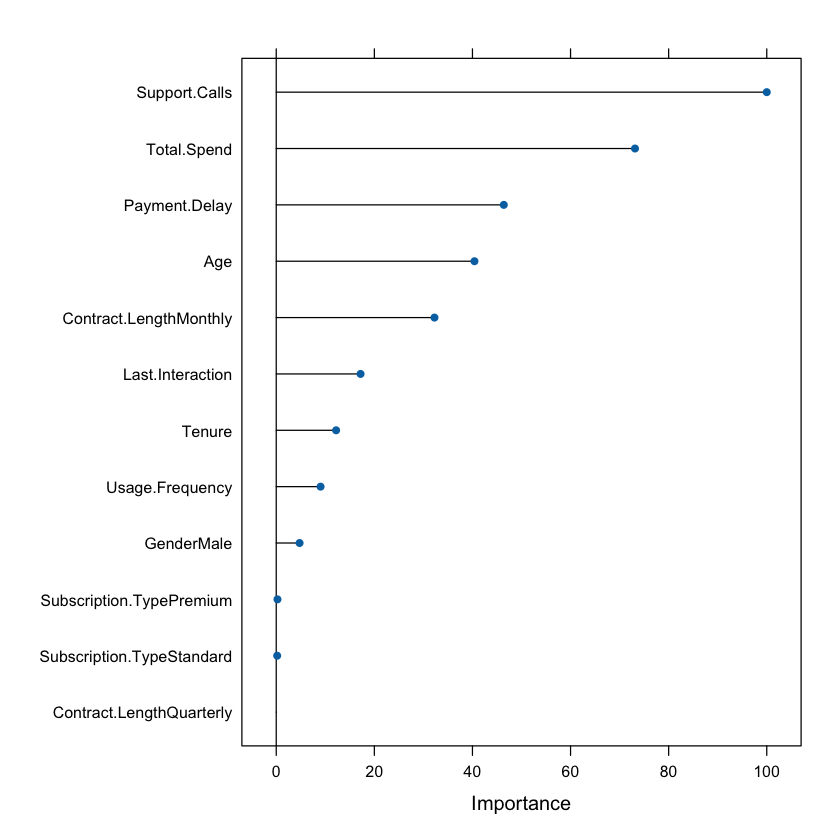

In [62]:
plot(varImp(rf.model))

## Coefficient Analysis

In [64]:
summary(cv.model.aic$finalModel)


Call:
NULL

Coefficients:
                            Estimate Std. Error  z value Pr(>|z|)    
(Intercept)               -1.287e+00  2.728e-02  -47.172  < 2e-16 ***
Age                        2.322e-02  3.696e-04   62.823  < 2e-16 ***
GenderMale                -7.270e-01  9.233e-03  -78.745  < 2e-16 ***
Tenure                    -8.529e-04  2.599e-04   -3.282  0.00103 ** 
Usage.Frequency           -1.314e-02  5.210e-04  -25.218  < 2e-16 ***
Support.Calls              4.058e-01  1.770e-03  229.304  < 2e-16 ***
Payment.Delay              8.408e-02  5.794e-04  145.110  < 2e-16 ***
Subscription.TypePremium  -7.831e-02  1.101e-02   -7.115 1.12e-12 ***
Subscription.TypeStandard -6.927e-02  1.101e-02   -6.290 3.17e-10 ***
Contract.LengthMonthly     2.092e+00  1.466e-02  142.711  < 2e-16 ***
Contract.LengthQuarterly  -9.615e-03  9.540e-03   -1.008  0.31357    
Total.Spend               -3.152e-03  2.028e-05 -155.448  < 2e-16 ***
Last.Interaction           3.264e-02  5.349e-04   61.020  < 2e-

In [84]:
coef.table <- summary(cv.model.aic$finalModel)$coefficients
odds.ratio <- exp(coef.table[, 1])
ci <- exp(confint.default(cv.model.aic$finalModel))

result <- data.frame(
  Feature     = rownames(coef.table),
  Coefficient = round(coef.table[, 1], 3),
  Odds.Ratio  = round(odds.ratio, 3),
  CI.Lower    = round(ci[, 1], 3),
  CI.Upper    = round(ci[, 2], 3),
  P.Value     = format(coef.table[, 4], digits = 3)
)
print(result, row.names = FALSE)

                   Feature Coefficient Odds.Ratio CI.Lower CI.Upper   P.Value
               (Intercept)      -1.287      0.276    0.262    0.291  0.00e+00
                       Age       0.023      1.023    1.023    1.024  0.00e+00
                GenderMale      -0.727      0.483    0.475    0.492  0.00e+00
                    Tenure      -0.001      0.999    0.999    1.000  1.03e-03
           Usage.Frequency      -0.013      0.987    0.986    0.988 2.56e-140
             Support.Calls       0.406      1.500    1.495    1.506  0.00e+00
             Payment.Delay       0.084      1.088    1.086    1.089  0.00e+00
  Subscription.TypePremium      -0.078      0.925    0.905    0.945  1.12e-12
 Subscription.TypeStandard      -0.069      0.933    0.913    0.953  3.17e-10
    Contract.LengthMonthly       2.092      8.102    7.872    8.338  0.00e+00
  Contract.LengthQuarterly      -0.010      0.990    0.972    1.009  3.14e-01
               Total.Spend      -0.003      0.997    0.997    0.

## Overall Comparison 

In [82]:
res.original <- eval_model(cv.model.original, df.test)
res.aic      <- eval_model(cv.model.aic, df.test.new)
res.bic      <- eval_model(cv.model.bic, df.test.new)
res.rf       <- eval_model(rf.model, df.test.new)

all.results <- rbind(res.original, res.aic, res.bic, res.rf)
all.results$Model <- c("LR Original", "LR AIC (Re-split)", "LR BIC (Re-split)", "RF (Re-split)")
all.results <- all.results[, c("Model", "Accuracy", "Sensitivity", "Specificity", "F1", "AUC")]

print(all.results, row.names = FALSE)

          Reference
Prediction     0     1
         0  6566   287
         1 27315 30206
 Accuracy Sensitivity Specificity     F1    AUC
   0.5712      0.9906      0.1938 0.6864 0.6831
          Reference
Prediction     0     1
         0 37954  8557
         1  6854 47677
 Accuracy Sensitivity Specificity     F1    AUC
   0.8475      0.8478       0.847 0.8609 0.9084
          Reference
Prediction     0     1
         0 37960  8560
         1  6848 47674
 Accuracy Sensitivity Specificity     F1    AUC
   0.8475      0.8478      0.8472 0.8609 0.9083
          Reference
Prediction     0     1
         0 38491   180
         1  6317 56054
 Accuracy Sensitivity Specificity     F1    AUC
   0.9357      0.9968       0.859 0.9452 0.9529
             Model Accuracy Sensitivity Specificity     F1    AUC
       LR Original   0.5712      0.9906      0.1938 0.6864 0.6831
 LR AIC (Re-split)   0.8475      0.8478      0.8470 0.8609 0.9084
 LR BIC (Re-split)   0.8475      0.8478      0.8472 0.8609 0.9